© 2026 by Tamás Takács is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

# Gyártósori Minőségellenőrzés

> **[Magyar MI Diákolimpia Online Válogató 2026/B](https://www.kaggle.com/competitions/magyar-mi-diakolimpia-online-valogato-2026-b)**
>
>
> Ez a notebook a verseny lezárása után készült **oktatási céllal**. Bemutatjuk az adatok feltárását, az alap megoldásokat, majd lépésről lépésre eljutunk a félig felügyelt tanulás (semi-supervised learning) módszereiig, amelyekkel a legjobb eredmények elérhetők voltak.

## Tartalomjegyzék

1. [Adatok betöltése és áttekintése](#1)
2. [Feltáró adatelemzés (EDA)](#2)
3. [Baseline modellek, csak címkézett adat](#3)
4. [Félig felügyelt tanulás (SSL), a címkézetlen adat felhasználása](#4)
5. [Per-klaszter modellek](#5)
6. [Pseudo-labeling](#6)
7. [Eredmények összehasonlítása](#7)

## A feladat összefoglalása

A verseny egy **gyártósori minőségellenőrzési** feladatot modellezett, ahol szenzor- és folyamatadatok alapján kellett megbecsülni, hogy egy termék **selejtes-e** (bináris klasszifikáció).

| Tulajdonság | Érték |
|-------------|-------|
| **Címkézett tanítóminták** | 150 |
| **Címkézetlen tanítóminták** | 12 850 |
| **Tesztminták** | 2 000 |
| **Jellemzők száma** | 33 numerikus + 1 kategorikus |
| **Célváltozó** | `Selejt` (0 vagy 1) |
| **Metrika** | AUC-ROC |

A fő kihívás: **nagyon kevés címkézett adat** áll rendelkezésre, viszont sok címkézetlen minta is elérhető. Ez klasszikus **félig felügyelt tanulási** (SSL) helyzet.

<a name="1"></a>
# 1. Adatok betöltése és áttekintése

### Szükséges importok

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, roc_curve, silhouette_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
np.random.seed(42)

%matplotlib inline

### Adatok beolvasása

A verseny négy fájlt biztosított:
- `train_labeled.csv`: 150 címkézett minta (szenzor jellemzők + `Selejt` célváltozó)
- `train_unlabeled.csv`: 12 850 címkézetlen minta (ugyanazok a jellemzők, de `Selejt` nélkül)
- `test.csv`: 2 000 tesztminta (predikciót kellett adni)
- `sample_submission.csv`: a beküldési formátum mintája

Mivel a verseny lezárult, a `solution.csv` is elérhető az értékeléshez.

In [2]:
import os

!gdown 146OjOF2-6dYXYnWUtkpLxZATR1w3YGpi -O train_labeled.csv
!gdown 1iXAkJErkAU9akpgEfZI7Lmtc0jq0_cDP -O train_unlabeled.csv
!gdown 1hQE4HkRRccOKfQbdZrmIQuxqe2_mJ0NF -O test.csv
!gdown 1kD-WRIkl44FAZQvHZcYGfmVehcLANLH2 -O solution.csv

KAGGLE_DIR = '/kaggle/input/magyar-mi-diakolimpia-online-valogato-2026-b/'
INPUT_DIR = KAGGLE_DIR if os.path.exists(KAGGLE_DIR) else './'

train_labeled = pd.read_csv(INPUT_DIR + 'train_labeled.csv')
train_unlabeled = pd.read_csv(INPUT_DIR + 'train_unlabeled.csv')
test_df = pd.read_csv(INPUT_DIR + 'test.csv')
solution = pd.read_csv(INPUT_DIR + 'solution.csv')

test_with_labels = test_df.merge(solution[['ID', 'Selejt']], on='ID')

print(f"\nCímkézett tanítóadatok:   {train_labeled.shape[0]:>6,} minta, {train_labeled.shape[1]} oszlop")
print(f"Címkézetlen tanítóadatok: {train_unlabeled.shape[0]:>6,} minta, {train_unlabeled.shape[1]} oszlop")
print(f"Tesztadatok:              {test_df.shape[0]:>6,} minta, {test_df.shape[1]} oszlop")
print(f"\nSelejtes arány (címkézett): {train_labeled['Selejt'].mean():.1%}")
print(f"Selejtes arány (teszt):     {test_with_labels['Selejt'].mean():.1%}")

Downloading...
From: https://drive.google.com/uc?id=146OjOF2-6dYXYnWUtkpLxZATR1w3YGpi
To: /content/train_labeled.csv
100% 95.3k/95.3k [00:00<00:00, 65.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1iXAkJErkAU9akpgEfZI7Lmtc0jq0_cDP
To: /content/train_unlabeled.csv
100% 8.10M/8.10M [00:00<00:00, 60.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hQE4HkRRccOKfQbdZrmIQuxqe2_mJ0NF
To: /content/test.csv
100% 1.26M/1.26M [00:00<00:00, 22.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1kD-WRIkl44FAZQvHZcYGfmVehcLANLH2
To: /content/solution.csv
100% 42.0k/42.0k [00:00<00:00, 52.0MB/s]

Címkézett tanítóadatok:      150 minta, 35 oszlop
Címkézetlen tanítóadatok: 12,850 minta, 34 oszlop
Tesztadatok:               2,000 minta, 34 oszlop

Selejtes arány (címkézett): 45.3%
Selejtes arány (teszt):     44.1%


In [3]:
train_labeled.head()

,ID,Hőmérséklet,Nyomás,Rezgés,Feszültség,Nyomaték,Szerszám_Kopás,Karbantartás_Óta_Eltelt_Idő,Páratartalom,Fordulat,...,Szenzor_11,Szenzor_12,Szenzor_13,Szenzor_14,Szenzor_15,Szenzor_16,Szenzor_17,Szenzor_18,Gyártósor,Selejt
0,ITEM_00000,75.907041,3.831936,51.472834,217.098007,38.316036,228.361172,155.478734,64.597543,1389.297668,...,-0.742682,-0.902517,1.159349,-0.379631,1.747762,-1.598339,-2.352235,0.497678,Vonal_E,1
1,ITEM_00001,81.242746,5.357322,25.553280,230.298673,48.384111,21.935034,69.234019,35.211917,1672.997915,...,-0.750481,1.624672,0.744649,-1.176670,0.750373,-0.302829,0.939427,-0.567894,Vonal_A,0
2,ITEM_00002,74.004248,3.971429,19.762415,205.499735,32.403428,167.193096,124.985486,72.651122,1183.049348,...,-1.450498,1.675769,1.374522,-0.527704,-0.278072,0.208900,0.857715,0.147685,Vonal_B,1
3,ITEM_00003,73.061348,2.542578,44.395338,233.853194,31.420680,113.907234,103.992968,61.111509,1490.947877,...,-1.158815,0.822962,1.127353,-1.257186,1.012118,0.170600,0.387113,1.377332,Vonal_C,0
4,ITEM_00004,82.929130,4.704838,18.821581,237.629698,67.618695,66.443431,69.115467,40.095704,1790.750438,...,-0.853669,-0.341559,2.165415,-0.228110,0.275952,0.705621,-0.695425,2.051832,Vonal_B,1


### Oszlopok leírásai

Az adathalmaz az alábbi jellemzőket tartalmazza:

**Fizikai szenzoradatok:**
- `Hőmérséklet`: gyártási hőmérséklet (°C)
- `Nyomás`: gyártási nyomás (bar)
- `Rezgés`: géprezgés mértéke (mm/s)
- `Feszültség`: elektromos feszültség (V)
- `Nyomaték`: mechanikai nyomaték (Nm)
- `Páratartalom`: környezeti páratartalom (%)
- `Fordulat`: forgási sebesség (RPM)

**Karbantartási adatok:**
- `Szerszám_Kopás`: szerszám kopottságának mértéke
- `Karbantartás_Óta_Eltelt_Idő`: utolsó karbantartás óta eltelt idő (óra)

**Származtatott jellemzők:**
- `Hő_Nyomás_Szorzat`, `Rezgés_Nyomaték_Arány`, `Kopás_Karb_Szorzat`, `Feszültség_Fordulat_Arány`, `Pára_Hő_Szorzat`

**Szenzor mérések:**
- `Szenzor_01` - `Szenzor_18`: egyéb szenzorértékek (ezek valójában **zajjellemzők**)

**Egyéb:**
- `Gyártósor`: kategorikus (Vonal_A - Vonal_E)
- `Selejt`: bináris célváltozó (csak a címkézett adatokban)

In [4]:
train_labeled.describe().round(2)

,Hőmérséklet,Nyomás,Rezgés,Feszültség,Nyomaték,Szerszám_Kopás,Karbantartás_Óta_Eltelt_Idő,Páratartalom,Fordulat,Hő_Nyomás_Szorzat,...,Szenzor_10,Szenzor_11,Szenzor_12,Szenzor_13,Szenzor_14,Szenzor_15,Szenzor_16,Szenzor_17,Szenzor_18,Selejt
count,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,...,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00
mean,72.55,3.95,30.86,225.06,42.46,131.51,104.94,56.90,1466.10,3.00,...,0.00,-0.10,0.05,-0.08,-0.07,0.27,-0.01,-0.14,-0.08,0.45
std,11.02,1.20,11.84,12.66,11.46,56.57,44.94,11.15,277.46,1.38,...,1.05,1.03,1.02,1.02,0.95,0.93,0.95,1.04,1.01,0.50
min,44.53,1.58,7.73,198.20,15.83,21.94,12.99,35.21,777.03,0.57,...,-2.82,-2.98,-2.24,-3.49,-2.45,-2.20,-2.72,-2.56,-2.43,0.00
25%,64.28,2.96,21.24,215.54,34.13,88.72,69.11,48.68,1269.73,2.10,...,-0.71,-0.75,-0.70,-0.71,-0.74,-0.35,-0.65,-0.97,-0.80,0.00
50%,72.06,3.84,28.06,225.27,41.32,116.68,100.40,55.79,1474.39,2.64,...,-0.02,-0.12,0.03,-0.05,0.01,0.30,-0.05,-0.03,-0.06,0.00
75%,79.48,4.78,39.39,235.98,49.66,167.17,130.18,63.47,1660.92,3.82,...,0.66,0.54,0.81,0.61,0.58,0.85,0.57,0.51,0.59,1.00
max,101.53,6.45,61.16,252.13,71.79,292.72,223.01,85.99,2184.07,6.87,...,2.66,2.23,2.59,2.17,2.88,2.27,2.50,3.07,2.62,1.00


<a name="2"></a>
# 2. Feltáró adatelemzés (EDA)

A feltáró elemzés célja, hogy megértsük az adatok struktúráját, eloszlásait és az esetleges rejtett mintázatokat. Különösen fontos, hogy **összehasonlítsuk a címkézett és címkézetlen adatokat**, ha hasonló az eloszlásuk, az jó jel az SSL módszerek szempontjából.

## 2.1 Célváltozó eloszlása

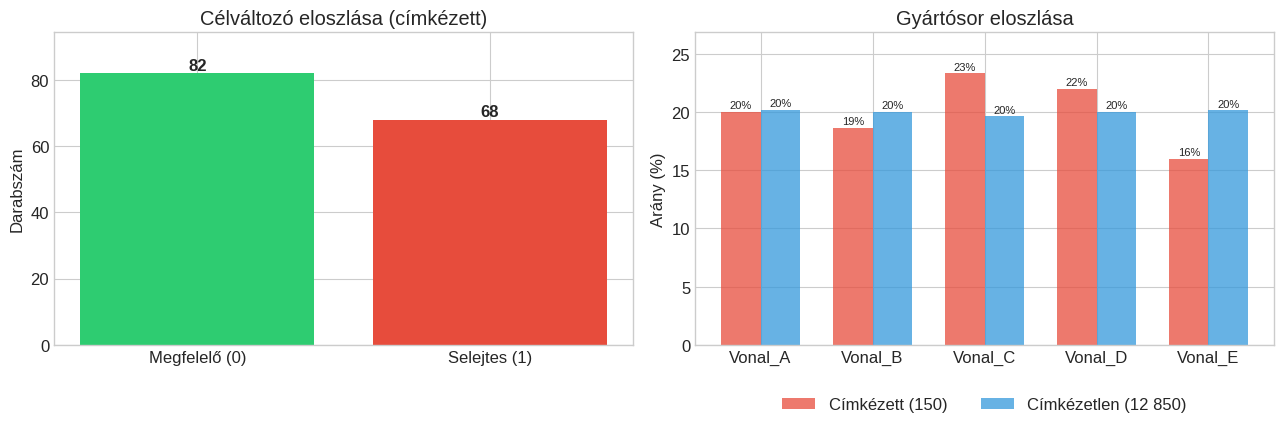

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

counts = train_labeled['Selejt'].value_counts().sort_index()
axes[0].bar(['Megfelelő (0)', 'Selejtes (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Célváltozó eloszlása (címkézett)')
axes[0].set_ylabel('Darabszám')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.15)

vonalak = sorted(train_labeled['Gyártósor'].unique())
x = np.arange(len(vonalak))
width = 0.35
all_pcts = []
for j, (label, df, color) in enumerate([
    ('Címkézett (150)', train_labeled, '#e74c3c'),
    ('Címkézetlen (12 850)', train_unlabeled, '#3498db'),
]):
    vc = df['Gyártósor'].value_counts()
    pcts = [vc.get(v, 0) / len(df) * 100 for v in vonalak]
    all_pcts.extend(pcts)
    bars = axes[1].bar(x + j * width, pcts, width, label=label, color=color, alpha=0.75)
    for bar, pct in zip(bars, pcts):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{pct:.0f}%', ha='center', fontsize=8)

axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(vonalak)
axes[1].set_title('Gyártósor eloszlása')
axes[1].set_ylabel('Arány (%)')
axes[1].set_ylim(0, max(all_pcts) * 1.15)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)

plt.tight_layout()
plt.show()

## 2.2 Jellemzők eloszlása

Vizsgáljuk meg a fő fizikai szenzoradatok eloszlását. Összehasonlítjuk a **címkézett** és **címkézetlen** adatokat, ha ezek hasonlóak, az azt jelenti, hogy a címkézetlen adatokból is tanulhatunk (pl. klaszterezéssel).

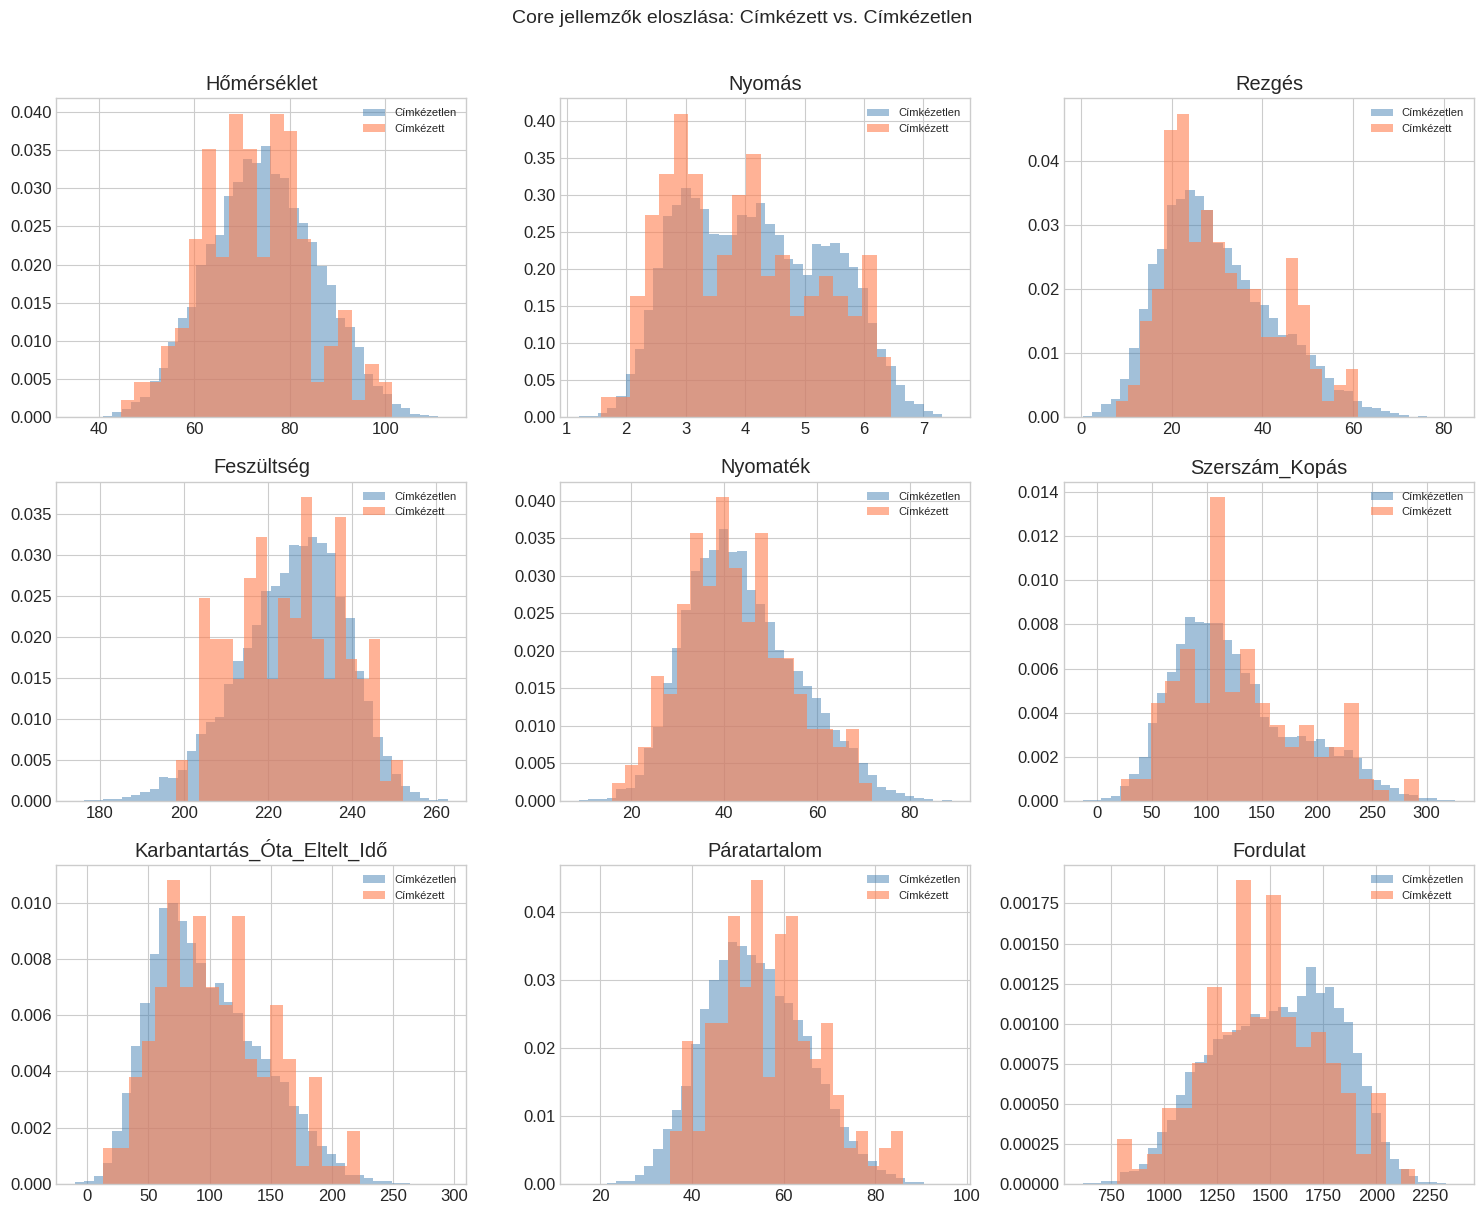

In [6]:
core_features = ['Hőmérséklet', 'Nyomás', 'Rezgés', 'Feszültség', 'Nyomaték',
                 'Szerszám_Kopás', 'Karbantartás_Óta_Eltelt_Idő', 'Páratartalom', 'Fordulat']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, feat in enumerate(core_features):
    ax = axes[i // 3, i % 3]
    ax.hist(train_unlabeled[feat], bins=40, alpha=0.5, density=True, label='Címkézetlen', color='steelblue')
    ax.hist(train_labeled[feat], bins=20, alpha=0.6, density=True, label='Címkézett', color='coral')
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Core jellemzők eloszlása: Címkézett vs. Címkézetlen', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Megfigyelés

A `Nyomás` jellemző eloszlása egyértelműen **többcsúcsú** (multimodális), ami arra utal, hogy **rejtett alcsoportok** (klaszterek) léteznek az adatban. Több más jellemző (pl. `Szerszám_Kopás`, `Fordulat`, `Rezgés`) eloszlása is szélesebb a szokásosnál, ami szintén kevert populációra utalhat, bár ez önmagában kevésbé egyértelmű.



## 2.3 Jellemzők és célváltozó kapcsolata

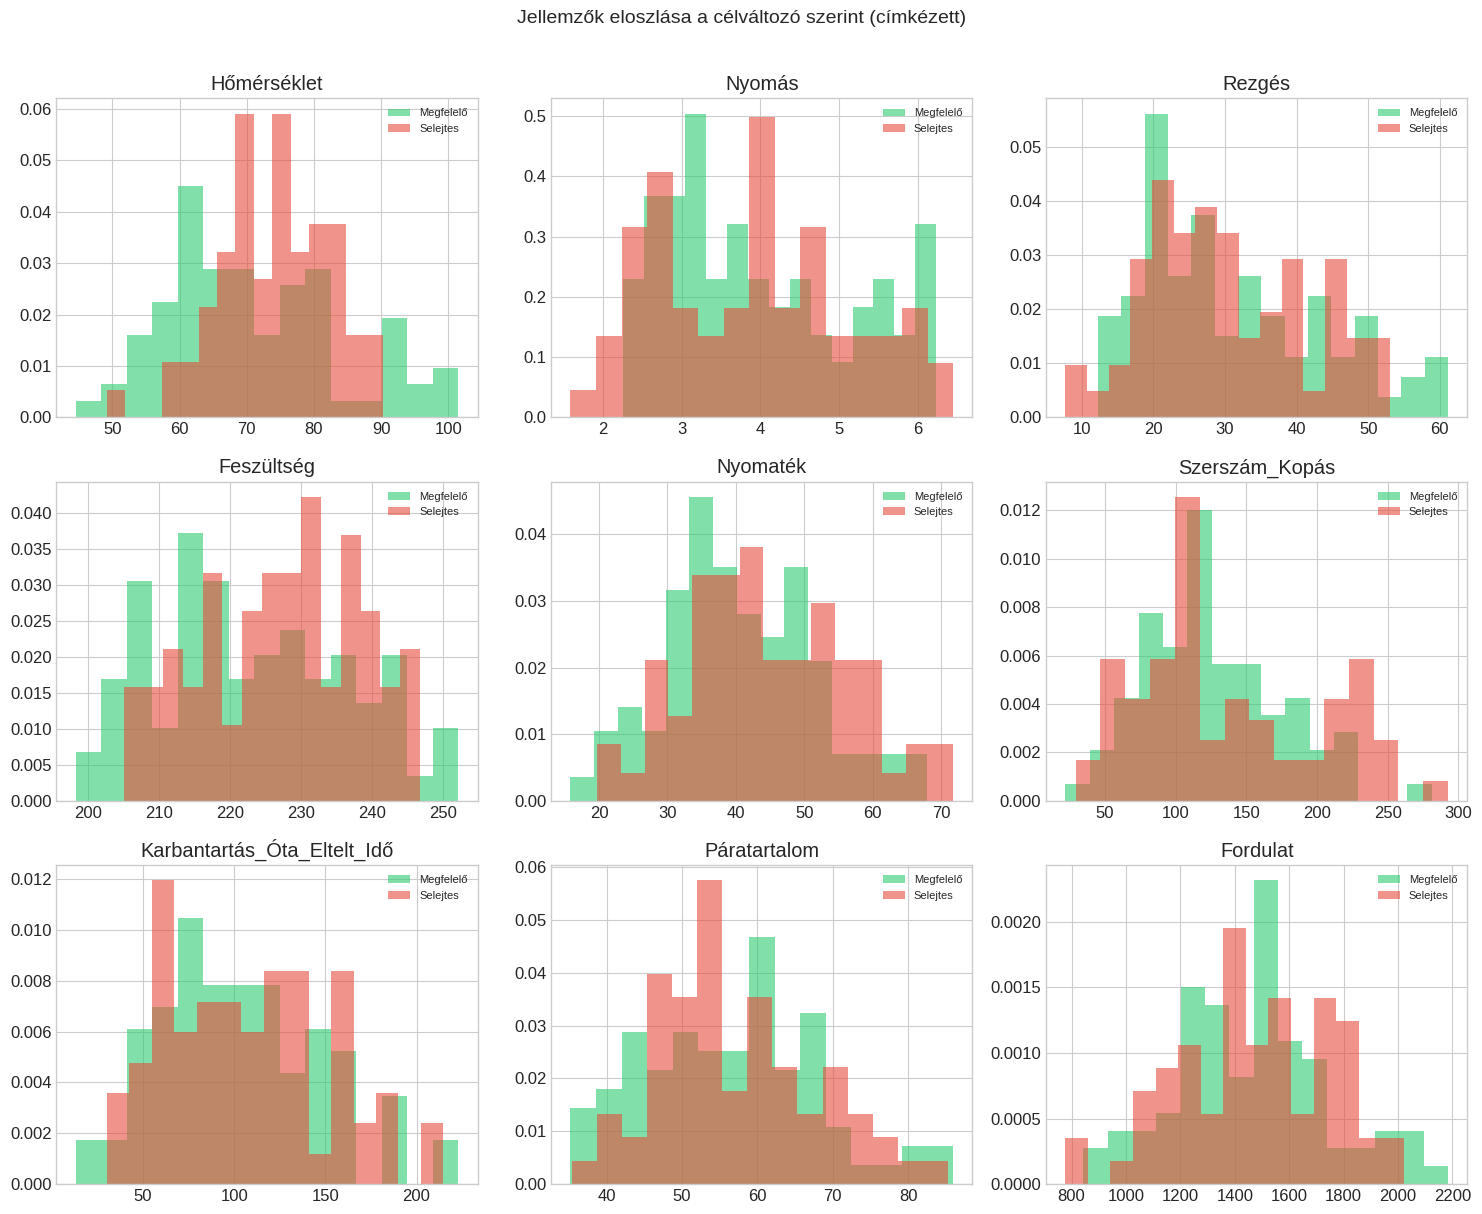

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, feat in enumerate(core_features):
    ax = axes[i // 3, i % 3]
    for val, color, label in [(0, '#2ecc71', 'Megfelelő'), (1, '#e74c3c', 'Selejtes')]:
        subset = train_labeled[train_labeled['Selejt'] == val]
        ax.hist(subset[feat], bins=15, alpha=0.6, density=True, label=label, color=color)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Jellemzők eloszlása a célváltozó szerint (címkézett)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Megfigyelés

Globálisan nézve a selejtesek és a megfelelők eloszlásai **nagyrészt átfednek**, egyetlen jellemző sem választja el őket egyértelműen. Ez azért van, mert a selejt **más-más jellemzőktől függ a különböző alcsoportokban** (rejtett állapotokban). Ezt globálisan a modell nem tudja hatékonyan megtanulni, különösen 150 mintából.



## 2.4 Korrelációs mátrix

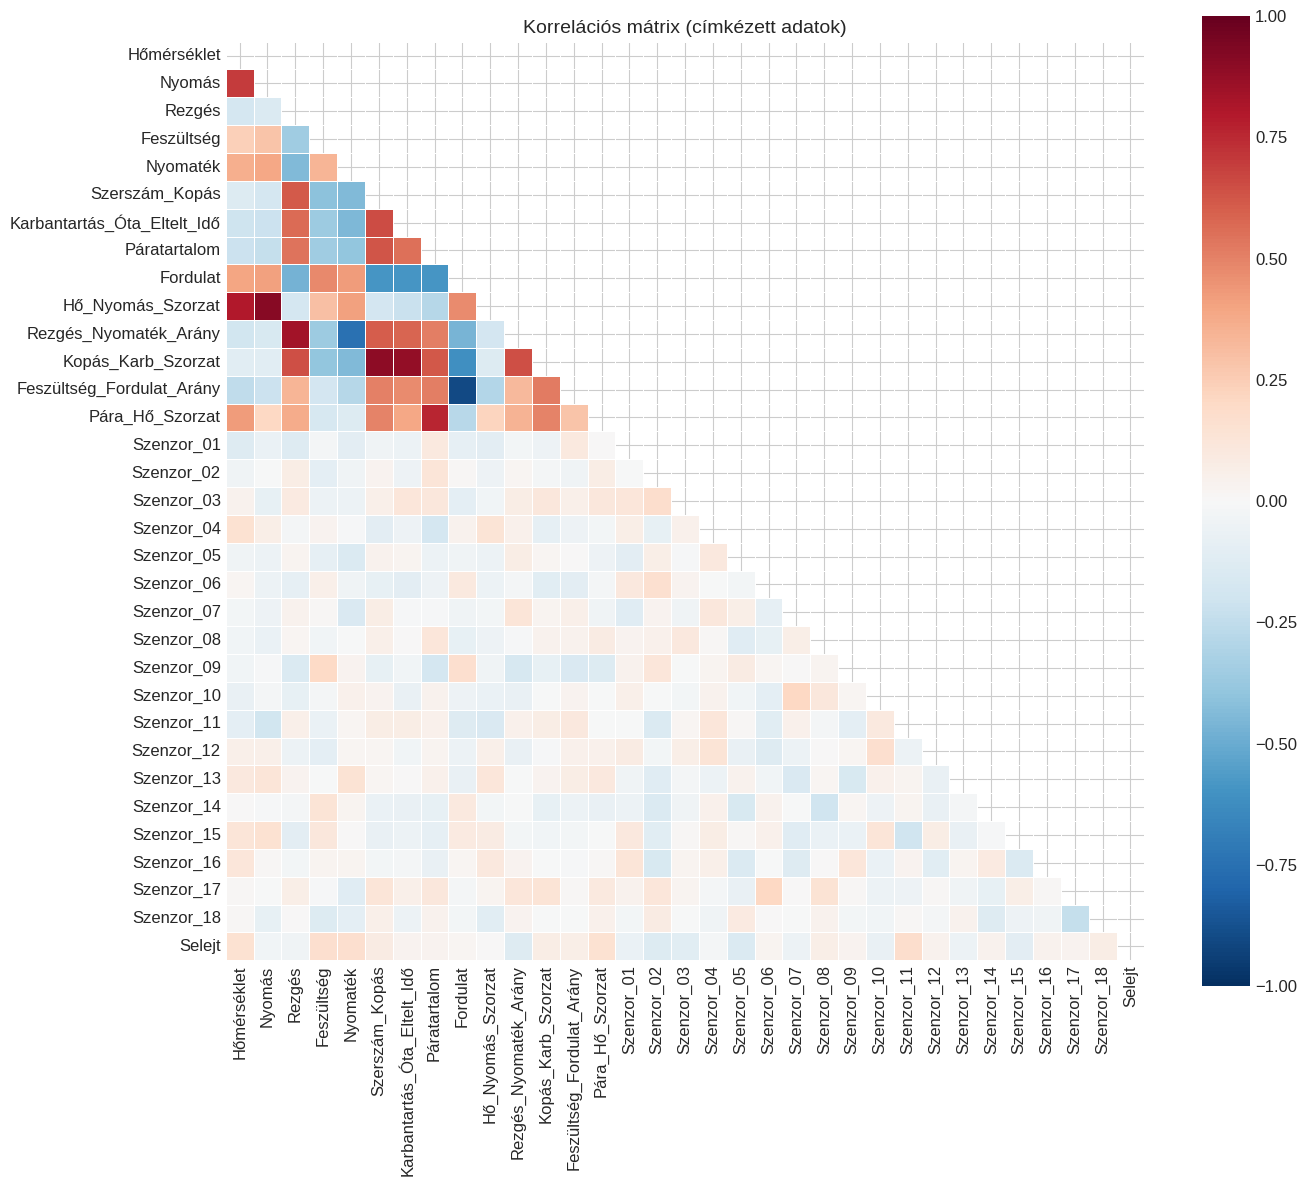


A Selejt változóval való korreláció (top 10 legerősebb):
  Szenzor_11                           +0.178
  Nyomaték                             +0.170
  Feszültség                           +0.167
  Pára_Hő_Szorzat                      +0.153
  Hőmérséklet                          +0.149
  Szenzor_05                           −0.142
  Szenzor_02                           −0.139
  Rezgés_Nyomaték_Arány                −0.128
  Szenzor_03                           −0.115
  Szenzor_15                           −0.106


In [8]:
numeric_cols = train_labeled.select_dtypes(include=[np.number]).columns.drop('ID', errors='ignore')
corr = train_labeled[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, fmt='.1f',
            annot=False)
ax.set_title('Korrelációs mátrix (címkézett adatok)', fontsize=14)
plt.tight_layout()
plt.show()

# A célváltozóval való korreláció
target_corr = corr['Selejt'].drop('Selejt')
top10 = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(10)
print("\nA Selejt változóval való korreláció (top 10 legerősebb):")
for feat, val in top10.items():
    direction = "+" if val > 0 else "−"
    print(f"  {feat:35s}  {direction}{abs(val):.3f}")

### Megfigyelés

A korrelációk a célváltozóval meglehetősen **gyengék**. Ez nem meglepő: mint látni fogjuk, a selejt különböző jellemzőktől függ az adatok különböző alcsoportjaiban. Globális lineáris korreláció ezért nem mutathat erős összefüggést.

A **Szenzor_01 - Szenzor_18** jellemzők szinte egyáltalán nem korrelálnak semmivel.

## 2.5 PCA vizualizáció

A főkomponens-elemzés (PCA) segít megjeleníteni a többdimenziós adatokat 2D-ben. Ha klaszterstruktúra van az adatban, az itt is megmutatkozik.

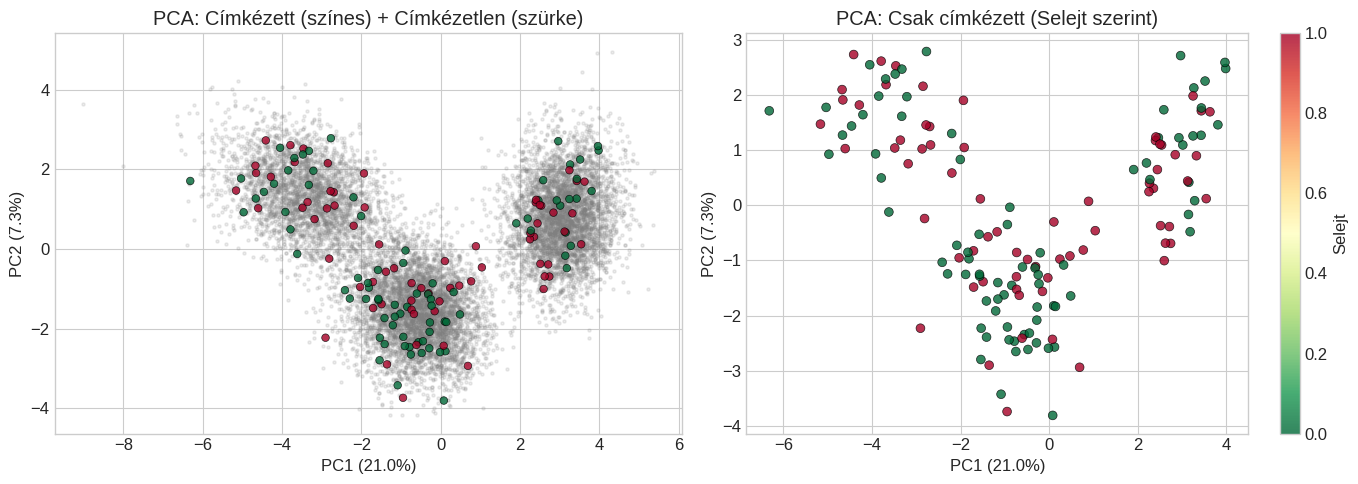


Megmagyarázott variancia (PC1 + PC2): 28.3%


In [9]:
# Előkészítés: LabelEncoder és StandardScaler
le = LabelEncoder()
all_lines = pd.concat([train_labeled['Gyártósor'], train_unlabeled['Gyártósor'], test_df['Gyártósor']])
le.fit(all_lines)

def prep(df):
    """Jellemzők előkészítése: Gyártósor kódolása, ID és Selejt eltávolítása."""
    df = df.copy()
    y = df.pop('Selejt') if 'Selejt' in df.columns else None
    df.drop(columns=['ID'], errors='ignore', inplace=True)
    df['Gyártósor'] = le.transform(df['Gyártósor'])
    return df, y

X_labeled, y_labeled = prep(train_labeled)
X_test, y_test = prep(test_with_labels) # Use test_with_labels to get true y_test
X_unlabeled, _ = prep(train_unlabeled)

scaler = StandardScaler()
X_labeled_s = scaler.fit_transform(X_labeled)
X_test_s = scaler.transform(X_test)
X_unlabeled_s = scaler.transform(X_unlabeled)

# PCA az összes tanítóadatra (címkézett + címkézetlen)
X_all = np.vstack([X_labeled_s, X_unlabeled_s])
pca = PCA(n_components=2)
X_all_2d = pca.fit_transform(X_all)
X_labeled_2d = X_all_2d[:len(X_labeled)]
X_unlabeled_2d = X_all_2d[len(X_labeled):]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Címkézetlen adatok (klaszterstruktúra)
axes[0].scatter(X_unlabeled_2d[:, 0], X_unlabeled_2d[:, 1], alpha=0.15, s=5, c='gray')
axes[0].scatter(X_labeled_2d[:, 0], X_labeled_2d[:, 1], alpha=0.8, s=30,
               c=y_labeled, cmap='RdYlGn_r', edgecolors='black', linewidths=0.5)
axes[0].set_title('PCA: Címkézett (színes) + Címkézetlen (szürke)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Csak címkézett, célváltozó szerint színezve
scatter = axes[1].scatter(X_labeled_2d[:, 0], X_labeled_2d[:, 1], alpha=0.8, s=40,
                          c=y_labeled, cmap='RdYlGn_r', edgecolors='black', linewidths=0.5)
axes[1].set_title('PCA: Csak címkézett (Selejt szerint)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter, ax=axes[1], label='Selejt')

plt.tight_layout()
plt.show()

print(f"\nMegmagyarázott variancia (PC1 + PC2): {pca.explained_variance_ratio_[:2].sum():.1%}")


### Megfigyelés

A PCA ábrán jól látható, hogy az adatban **2-3 elkülöníthető csoport** van. Ez a klaszterstruktúra mind a címkézett, mind a címkézetlen adatban megjelenik. A selejtesek és a megfelelők **nem válnak szét egyértelműen** a globális PCA térben, de figyeljük meg, hogy **klaszterenként** másként oszlanak el!



<a name="3"></a>
# 3. Baseline modellek (csak címkézett adat)

Először tanítunk modelleket **kizárólag a 150 címkézett mintán**, a címkézetlen adatok felhasználása nélkül. Ez adja a kiindulópontot, amihez az SSL módszereket hasonlítjuk.

### Segédfüggvények

In [10]:
# Eredmények gyűjtése
results = {}

def evaluate(name, y_true, y_prob):
    """Modell kiértékelése és eredmény mentése."""
    auc = roc_auc_score(y_true, y_prob)
    results[name] = auc
    print(f"{name}: AUC-ROC = {auc:.4f}")

## 3.1 Logisztikus Regresszió

A **legegyszerűbb baseline**: lineáris modell, amely valószínűségeket ad vissza. A starter notebook is ezt tartalmazta.

In [11]:
# Logisztikus regresszió
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_labeled_s, y_labeled)
evaluate("Logisztikus Regresszió", y_test, lr.predict_proba(X_test_s)[:, 1])

Logisztikus Regresszió: AUC-ROC = 0.6230


## 3.2 Random Forest

Ensemble modell, amely döntési fák szavazatával jósol. Nem igényel skálázást (az eredeti jellemzőkön tanítjuk).

In [12]:
# Random Forest (nem skálázott adaton)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_labeled, y_labeled)
evaluate("Random Forest", y_test, rf.predict_proba(X_test)[:, 1])

Random Forest: AUC-ROC = 0.7052


## 3.3 Gradient Boosting (GBM)

A **Gradient Boosting** jellemzően a legerősebb táblázatos modell. Szekvenciálisan épít döntési fákat, mindegyik az előző hibáját javítja.

In [13]:
# GBM (alap)
gbm = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
gbm.fit(X_labeled_s, y_labeled)
evaluate("GBM (alap)", y_test, gbm.predict_proba(X_test_s)[:, 1])

# GBM (finomhangolt)
gbm_tuned = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.08, random_state=42)
gbm_tuned.fit(X_labeled_s, y_labeled)
evaluate("GBM (finomhangolt)", y_test, gbm_tuned.predict_proba(X_test_s)[:, 1])

GBM (alap): AUC-ROC = 0.7286
GBM (finomhangolt): AUC-ROC = 0.7433


A legjobb baseline (csak címkézett adat) a **finomhangolt GBM** volt, de az AUC értéke bőven javítható. 150 mintából, 33 jellemzővel (melyből 18 zaj), a globális modellnek nehéz dolga van.

> **Hogyan használhatjuk fel a 12 850 címkézetlen mintát a javulás érdekében?**


<a name="4"></a>
# 4. Félig felügyelt tanulás (SSL)

A félig felügyelt tanulás (Semi-Supervised Learning) azt jelenti, hogy **a címkézetlen adatokból is tanulunk**, nem közvetlenül a címkéket, hanem az adatok **struktúráját**.

### Az adatok rejtett struktúrája

A kulcsfontosságú felismerés: az adatokban **3 rejtett gépi állapot** (klaszter) van, amelyekben a selejt **más-más jellemzőktől** függ:

| Állapot | Selejtet növeli | Selejtet csökkenti | Speciális |
|---------|-----------------|--------------------|-----------|
| **0** | Hőmérséklet, Rezgés | Nyomás | Hőmérséklet pozitív hatás |
| **1** | Nyomaték, Karbantartás | Hőmérséklet | Hőmérséklet **negatív** hatás! |
| **2** | Szerszám_Kopás, Feszültség | Rezgés | Rezgés **negatív** hatás! |

Ez azt jelenti, hogy ha a Hőmérséklet nő:
- Az **0-s állapotban** ez **növeli** a selejt esélyét
- Az **1-es állapotban** ez **csökkenti** a selejt esélyét

Egy globális modell ezt az ellentmondást nem tudja feloldani! Viszont ha az adatokat **klaszterekre bontjuk**, minden klaszterben a kapcsolat egyszerű és kevés mintából is megtanulható.

## 4.1 Klaszterezés KMeans-szel

A `KMeans` algoritmust az **összes** tanítóadaton (címkézett + címkézetlen) futtatjuk, K=3 klaszterrel.

In [14]:
# KMeans klaszterezés a teljes tanítóadaton (címkézett + címkézetlen)
km = KMeans(n_clusters=3, random_state=42, n_init=20)
km.fit(X_all)

cluster_labeled = km.labels_[:len(X_labeled)]
cluster_unlabeled = km.labels_[len(X_labeled):]
cluster_test = km.predict(X_test_s)

print("Klaszter eloszlás (összes tanítóadat):")
unique, counts = np.unique(km.labels_, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Klaszter {u}: {c:>5,} minta ({c/len(km.labels_):.1%})")

print(f"\nKlaszter eloszlás (címkézett, ~50 minta/klaszter):")
for cl in range(3):
    n = (cluster_labeled == cl).sum()
    defect_rate = y_labeled.values[cluster_labeled == cl].mean()
    print(f"  Klaszter {cl}: {n:>3} minta, selejt arány = {defect_rate:.1%}")

Klaszter eloszlás (összes tanítóadat):
  Klaszter 0: 3,242 minta (24.9%)
  Klaszter 1: 5,167 minta (39.7%)
  Klaszter 2: 4,591 minta (35.3%)

Klaszter eloszlás (címkézett, ~50 minta/klaszter):
  Klaszter 0:  40 minta, selejt arány = 52.5%
  Klaszter 1:  70 minta, selejt arány = 38.6%
  Klaszter 2:  40 minta, selejt arány = 50.0%


### Klaszterek vizualizációja PCA-val

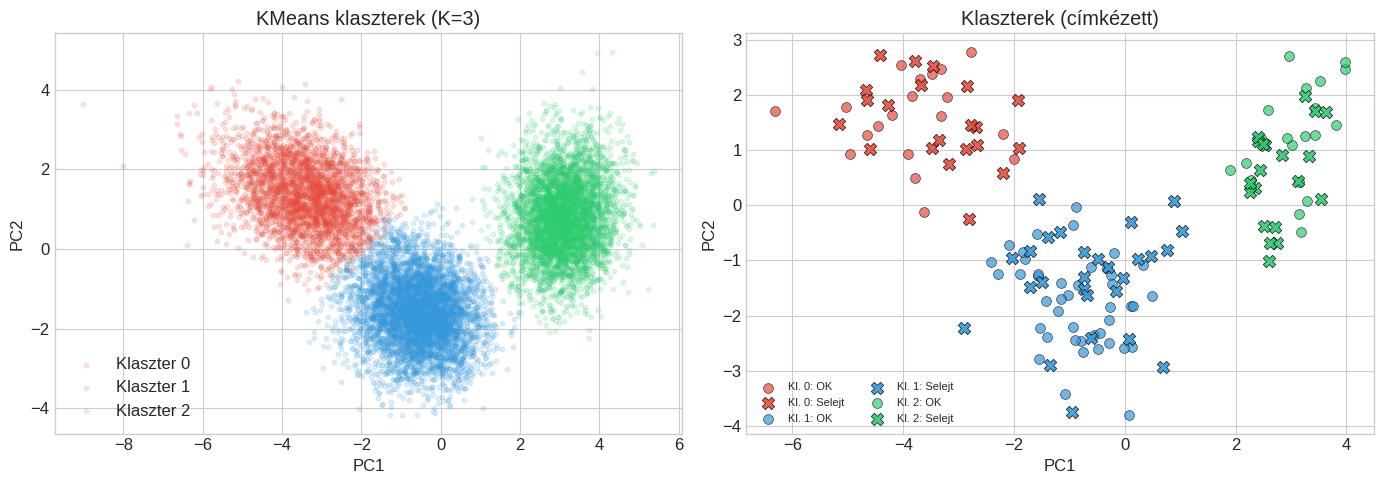

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#3498db', '#2ecc71']

# Klaszterek az összes adaton
for cl in range(3):
    mask = km.labels_ == cl
    axes[0].scatter(X_all_2d[mask, 0], X_all_2d[mask, 1], alpha=0.15, s=10, c=colors[cl], label=f'Klaszter {cl}')
axes[0].set_title('KMeans klaszterek (K=3)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Klaszterek a címkézett adaton, selejt jelöléssel
for cl in range(3):
    mask = cluster_labeled == cl
    x = X_labeled_2d[mask]
    y = y_labeled.values[mask]
    axes[1].scatter(x[y == 0, 0], x[y == 0, 1], marker='o', s=50, c=colors[cl], alpha=0.7,
                   edgecolors='black', linewidths=0.5, label=f'Kl. {cl}: OK')
    axes[1].scatter(x[y == 1, 0], x[y == 1, 1], marker='X', s=80, c=colors[cl], alpha=0.9,
                   edgecolors='black', linewidths=0.5, label=f'Kl. {cl}: Selejt')
axes[1].set_title('Klaszterek (címkézett)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## 4.2 Hogyan válasszuk meg K-t?

A K megválasztása fontos kérdés. Két elterjedt módszer:

- **Elbow módszer**: A klaszteren belüli szórásnégyzet-összeg (inertia) csökkenését figyeljük K függvényében. Ahol a görbe „megtörik", ott van az optimális K.
- **Silhouette score**: Azt méri, mennyire jól illeszkedik minden pont a saját klaszterébe a szomszédos klaszterhez képest (magasabb = jobb). A Silhouette gyakran K=2-nél a legmagasabb (mert az a legtriviálisabb felosztás), de a K=3-nál megjelenő **második csúcs** vagy **könyök** azt jelzi, hogy az adat természetes struktúrája 3 csoportot tartalmaz.

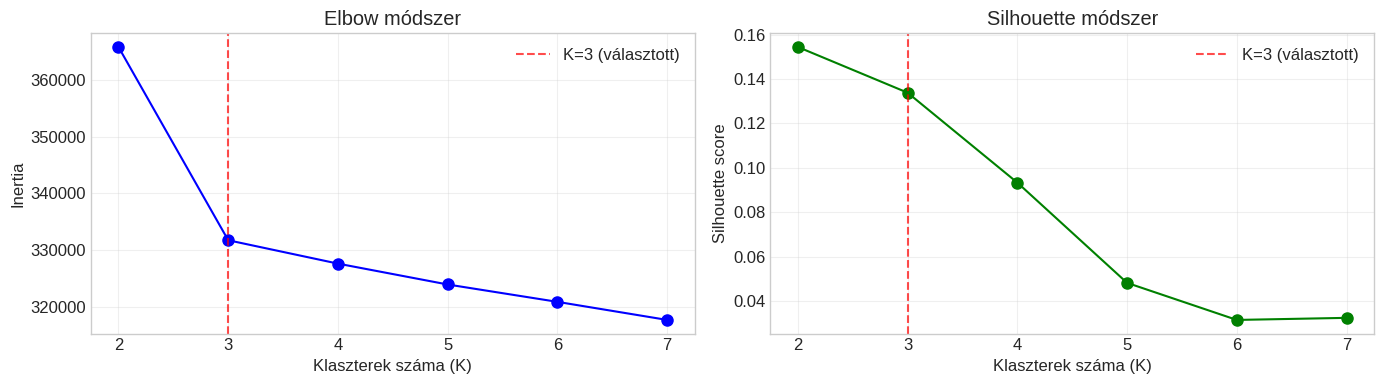


 Legjobb Silhouette score: K=2 (0.154)


In [16]:
inertias = []
silhouettes = []
K_range = range(2, 8)
for k in K_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_temp.fit_predict(X_all)
    inertias.append(km_temp.inertia_)
    silhouettes.append(silhouette_score(X_all, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, 'bo-', markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 (választott)')
axes[0].set_xlabel('Klaszterek száma (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow módszer')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'go-', markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 (választott)')
axes[1].set_xlabel('Klaszterek száma (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette módszer')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"\n Legjobb Silhouette score: K={best_k} ({max(silhouettes):.3f})")

## 4.3 Klaszter mint jellemző

Az első, egyszerűbb SSL megközelítés: a klaszter-hozzárendelést mint **új jellemzőt** adjuk a modellhez. Ez nem per-klaszter tanítás, hanem egyetlen globális modell, amely a klaszter-információt is felhasználja.

In [17]:
# Klaszter-ID hozzáadása mint jellemző
X_labeled_cl = np.column_stack([X_labeled_s, cluster_labeled])
X_test_cl = np.column_stack([X_test_s, cluster_test])

gbm_cl = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
gbm_cl.fit(X_labeled_cl, y_labeled)
evaluate("SSL: Klaszter mint feature (K=3)", y_test, gbm_cl.predict_proba(X_test_cl)[:, 1])

SSL: Klaszter mint feature (K=3): AUC-ROC = 0.7340


A klaszter-feature **némi javulást** hoz, de nem elegendő. A klaszter-feature lehetővé teszi az elágazást, de nem garantálja, hogy a modell meg is találja ezt a struktúrát.




<a name="5"></a>
# 5. Per-klaszter modellek

Az igazi áttörés: **minden klaszterben külön modellt** tanítunk. Így:
- Minden modell csak ~50 címkézett mintát lát
- De csak 2-3 releváns jellemzőt kell megtanulnia
- A zajjellemzők hatása kisebb, a jel erősebb

## 5.1 Per-klaszter Logisztikus Regresszió

In [27]:
# Per-klaszter Logisztikus Regresszió
pred_lr = np.zeros(len(X_test))
for cl in range(3):
    mask_l = cluster_labeled == cl
    mask_t = cluster_test == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(X_labeled_s[mask_l], y_labeled.values[mask_l])
    pred_lr[mask_t] = m.predict_proba(X_test_s[mask_t])[:, 1]
    print(f"Klaszter {cl}: {mask_l.sum()} tanítóminta → {mask_t.sum()} tesztminta")

evaluate("SSL: Per-klaszter LogReg (K=3)", y_test, pred_lr)

Klaszter 0: 40 tanítóminta → 525 tesztminta
Klaszter 1: 70 tanítóminta → 778 tesztminta
Klaszter 2: 40 tanítóminta → 697 tesztminta
SSL: Per-klaszter LogReg (K=3): AUC-ROC = 0.7657


Egy egyszerű **logisztikus regresszió**, klaszterenként tanítva, **jobb** mint a globális GBM. Ez mutatja, mennyire hatékonyan kihasználja a klaszterstruktúrát ez a megközelítés.



## 5.2 Per-klaszter GBM

In [28]:
# Per-klaszter GBM
pred_gbm = np.zeros(len(X_test))
for cl in range(3):
    mask_l = cluster_labeled == cl
    mask_t = cluster_test == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue
    m = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    m.fit(X_labeled_s[mask_l], y_labeled.values[mask_l])
    pred_gbm[mask_t] = m.predict_proba(X_test_s[mask_t])[:, 1]

evaluate("SSL: Per-klaszter GBM (K=3)", y_test, pred_gbm)

SSL: Per-klaszter GBM (K=3): AUC-ROC = 0.7741


## 5.3 Miért nem működik K=5?

Ha túl sok klasztert választunk, minden klaszterben kevesebb tanítóminta lesz, és a modellek gyengébbek lesznek.

In [31]:
# K=5 klaszterezés
km5 = KMeans(n_clusters=5, random_state=42, n_init=20)
km5.fit(X_all)
cl5_labeled = km5.labels_[:len(X_labeled)]
cl5_test = km5.predict(X_test_s)

pred_k5 = np.zeros(len(X_test))
for cl in range(5):
    mask_l = cl5_labeled == cl
    mask_t = cl5_test == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue
    m = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    m.fit(X_labeled_s[mask_l], y_labeled.values[mask_l])
    pred_k5[mask_t] = m.predict_proba(X_test_s[mask_t])[:, 1]

evaluate("SSL: Per-klaszter GBM (K=5)", y_test, pred_k5)

SSL: Per-klaszter GBM (K=5): AUC-ROC = 0.6672


K=5 esetén a klaszterenként ~30 minta már kevés a modelleknek.

<a name="6"></a>
# 6. Pseudo-labeling

A **pseudo-labeling** az SSL egyik legismertebb technikája. Az ötlet:

1. Taníts egy modellt a címkézett adatokon
2. Jósold meg a címkézetlen adatok címkéit
3. A **magas konfidenciájú** predikciókat vedd be a tanítóhalmazba mint „pseudo-címkéket"
4. Taníts újra a kibővített adaton

## 6.1 Per-klaszter GBM + Pseudo-labeling (3 kör)

Minden klaszterben 3 körben bővítjük a tanítóhalmazt, fokozatosan lazítva a konfidencia-küszöböt.

In [32]:
pred_pseudo3 = np.zeros(len(X_test))

for cl in range(3):
    mask_l = cluster_labeled == cl
    mask_t = cluster_test == cl
    mask_u = cluster_unlabeled == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue

    n_labeled = mask_l.sum()
    n_unlabeled = mask_u.sum()
    X_cl = X_labeled_s[mask_l]
    y_cl = y_labeled.values[mask_l]
    X_u_cl = X_unlabeled_s[mask_u]

    print(f"Klaszter {cl}: {n_labeled} címkézett, {n_unlabeled} címkézetlen")

    prev_pseudo = 0
    for rnd in range(3):
        m = GradientBoostingClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, random_state=42 + rnd
        )
        m.fit(X_cl, y_cl)

        # Predikció a címkézetlen adatokra
        pr = m.predict_proba(X_u_cl)[:, 1]

        # Konfidencia-küszöb: egyre lazább
        threshold = 0.88 - rnd * 0.06
        high_conf = (pr > threshold) | (pr < 1 - threshold)

        if high_conf.sum() > 10:
            n_new = high_conf.sum() - prev_pseudo
            prev_pseudo = high_conf.sum()
            X_cl = np.vstack([X_labeled_s[mask_l], X_u_cl[high_conf]])
            y_cl = np.concatenate([y_labeled.values[mask_l], (pr[high_conf] > 0.5).astype(int)])
            print(f"  Kör {rnd+1}: küszöb={threshold:.2f}, "
                  f"{high_conf.sum()}/{n_unlabeled} minta elég konfídens (+{n_new} új) "
                  f"→ tanítóhalmaz: {len(y_cl)}")
        else:
            print(f"  Kör {rnd+1}: küszöb={threshold:.2f}, nem elég magas konfidenciájú minta")

    pred_pseudo3[mask_t] = m.predict_proba(X_test_s[mask_t])[:, 1]

print()
evaluate("SSL: Per-klaszter GBM + pseudo (3 kör)", y_test, pred_pseudo3)

Klaszter 0: 40 címkézett, 3202 címkézetlen
  Kör 1: küszöb=0.88, 2566/3202 minta elég konfídens (+2566 új) → tanítóhalmaz: 2606
  Kör 2: küszöb=0.82, 3102/3202 minta elég konfídens (+536 új) → tanítóhalmaz: 3142
  Kör 3: küszöb=0.76, 3145/3202 minta elég konfídens (+43 új) → tanítóhalmaz: 3185
Klaszter 1: 70 címkézett, 5097 címkézetlen
  Kör 1: küszöb=0.88, 4154/5097 minta elég konfídens (+4154 új) → tanítóhalmaz: 4224
  Kör 2: küszöb=0.82, 4872/5097 minta elég konfídens (+718 új) → tanítóhalmaz: 4942
  Kör 3: küszöb=0.76, 5039/5097 minta elég konfídens (+167 új) → tanítóhalmaz: 5109
Klaszter 2: 40 címkézett, 4551 címkézetlen
  Kör 1: küszöb=0.88, 3670/4551 minta elég konfídens (+3670 új) → tanítóhalmaz: 3710
  Kör 2: küszöb=0.82, 4343/4551 minta elég konfídens (+673 új) → tanítóhalmaz: 4383
  Kör 3: küszöb=0.76, 4475/4551 minta elég konfídens (+132 új) → tanítóhalmaz: 4515

SSL: Per-klaszter GBM + pseudo (3 kör): AUC-ROC = 0.7854


## 6.2 Per-klaszter: Pseudo-label mindent, majd újratanítás

Egy egyszerűbb variáns: az első modell predikciójával **az összes** címkézetlen mintát „megcímkézzük", majd egy erősebb modellt tanítunk a teljes (bővített) adaton.

In [33]:
pred_pseudo_all = np.zeros(len(X_test))

for cl in range(3):
    mask_l = cluster_labeled == cl
    mask_t = cluster_test == cl
    mask_u = cluster_unlabeled == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue

    # 1. lépés: tanítás a címkézett adatokon
    m1 = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    m1.fit(X_labeled_s[mask_l], y_labeled.values[mask_l])

    # 2. lépés: az összes címkézetlen minta pseudo-címkézése
    pr = m1.predict_proba(X_unlabeled_s[mask_u])[:, 1]

    # 3. lépés: újratanítás a teljes (eredeti + pseudo) adaton
    X_all_cl = np.vstack([X_labeled_s[mask_l], X_unlabeled_s[mask_u]])
    y_all_cl = np.concatenate([y_labeled.values[mask_l], (pr > 0.5).astype(int)])

    m2 = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.08, random_state=42)
    m2.fit(X_all_cl, y_all_cl)
    pred_pseudo_all[mask_t] = m2.predict_proba(X_test_s[mask_t])[:, 1]

    print(f"  Klaszter {cl}: {mask_l.sum()} eredeti + {mask_u.sum()} pseudo = {len(y_all_cl)} összesen")

print()
evaluate("SSL: Per-klaszter pseudo-ALL", y_test, pred_pseudo_all)

  Klaszter 0: 40 eredeti + 3202 pseudo = 3242 összesen
  Klaszter 1: 70 eredeti + 5097 pseudo = 5167 összesen
  Klaszter 2: 40 eredeti + 4551 pseudo = 4591 összesen

SSL: Per-klaszter pseudo-ALL: AUC-ROC = 0.7712


## 6.4 Feature selection (a zajjellemzők elhagyása)

Eddig az összes 33 jellemzőt használtuk. De a `Szenzor_01`-`Szenzor_18` jellemzők **tiszta zaj**, a korrelációs elemzésnél láttuk, hogy szinte semmivel nem korrelálnak. A származtatott jellemzők (`Hő_Nyomás_Szorzat` stb.) pedig redundánsak.

Kevés mintával (klaszterenként ~50) a zajjellemzők **aktívan ártanak**: a modell túltanul rajtuk. Próbáljuk meg elhagyni őket!

In [45]:
# Csak a 9 core fizikai jellemző + Gyártósor
noise_cols = [f'Szenzor_{i:02d}' for i in range(1, 19)]
interaction_cols = ['Hő_Nyomás_Szorzat', 'Rezgés_Nyomaték_Arány',
                    'Kopás_Karb_Szorzat', 'Feszültség_Fordulat_Arány', 'Pára_Hő_Szorzat']
drop_cols = noise_cols + interaction_cols
keep_idx = [i for i, c in enumerate(X_labeled.columns) if c not in drop_cols]

X_labeled_core = X_labeled_s[:, keep_idx]
X_test_core = X_test_s[:, keep_idx]
X_unlabeled_core = X_unlabeled_s[:, keep_idx]

kept_names = [c for c in X_labeled.columns if c not in drop_cols]
print(f"Eredeti jellemzők: {X_labeled_s.shape[1]}")
print(f"Megtartott jellemzők ({len(keep_idx)}): {kept_names}")

Eredeti jellemzők: 33
Megtartott jellemzők (10): ['Hőmérséklet', 'Nyomás', 'Rezgés', 'Feszültség', 'Nyomaték', 'Szerszám_Kopás', 'Karbantartás_Óta_Eltelt_Idő', 'Páratartalom', 'Fordulat', 'Gyártósor']


In [46]:
# KMeans a tisztított jellemzőkkel
X_all_core = np.vstack([X_labeled_core, X_unlabeled_core])
km_core = KMeans(n_clusters=3, random_state=42, n_init=20).fit(X_all_core)
cl_core_l = km_core.labels_[:len(X_labeled)]
cl_core_u = km_core.labels_[len(X_labeled):]
cl_core_t = km_core.predict(X_test_core)

# Per-klaszter GBM + pseudo-labeling
pred_core_gbm = np.zeros(len(X_test))
for cl in range(3):
    mask_l = cl_core_l == cl
    mask_t = cl_core_t == cl
    mask_u = cl_core_u == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue
    X_cl = X_labeled_core[mask_l]
    y_cl = y_labeled.values[mask_l]
    X_u_cl = X_unlabeled_core[mask_u]
    for rnd in range(3):
        m = GradientBoostingClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, random_state=42 + rnd
        )
        m.fit(X_cl, y_cl)
        pr = m.predict_proba(X_u_cl)[:, 1]
        thr = 0.88 - rnd * 0.06
        hc = (pr > thr) | (pr < 1 - thr)
        if hc.sum() > 10:
            X_cl = np.vstack([X_labeled_core[mask_l], X_u_cl[hc]])
            y_cl = np.concatenate([y_labeled.values[mask_l], (pr[hc] > 0.5).astype(int)])
    pred_core_gbm[mask_t] = m.predict_proba(X_test_core[mask_t])[:, 1]

evaluate("SSL: Core feat. + GBM + pseudo (3 kör)", y_test, pred_core_gbm)

SSL: Core feat. + GBM + pseudo (3 kör): AUC-ROC = 0.8034


A zajjellemzők elhagyása önmagában **~3 százalékpontos javulást** hoz a GBM-nél! De ennél is tovább mehetünk.



## 6.5 LogReg mint optimális per-klaszter modell

Az adatgeneráló folyamat minden klaszterben **lineáris logit-függvénnyel** hozza létre a címkéket. Ez azt jelenti, hogy a logisztikus regresszió elméletileg **tökéletesen illeszkedik** a feladathoz (ha a megfelelő jellemzőkön tanítjuk.)

A GBM-mel az a probléma, hogy ~50 mintából hajlamos túltanulni, különösen ha a jellemzők száma nagy. A LogReg viszont kevés paraméterrel dolgozik, és jól általánosít kis mintákból is.

In [48]:
# Per-klaszter LogReg a core jellemzőkön
core_phys = ['Hőmérséklet', 'Nyomás', 'Rezgés', 'Feszültség', 'Nyomaték',
             'Szerszám_Kopás', 'Karbantartás_Óta_Eltelt_Idő', 'Páratartalom', 'Fordulat']
phys_idx = [list(X_labeled.columns).index(c) for c in core_phys]

X_labeled_phys = X_labeled_s[:, phys_idx]
X_test_phys = X_test_s[:, phys_idx]
X_unlabeled_phys = X_unlabeled_s[:, phys_idx]

# Klaszterezés a fizikai jellemzőkön
X_all_phys = np.vstack([X_labeled_phys, X_unlabeled_phys])
km_phys = KMeans(n_clusters=3, random_state=42, n_init=20).fit(X_all_phys)
cl_phys_l = km_phys.labels_[:len(X_labeled)]
cl_phys_u = km_phys.labels_[len(X_labeled):]
cl_phys_t = km_phys.predict(X_test_phys)

pred_core_lr = np.zeros(len(X_test))
for cl in range(3):
    mask_l = cl_phys_l == cl
    mask_t = cl_phys_t == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue
    m = LogisticRegression(max_iter=2000, random_state=42, C=10.0)
    m.fit(X_labeled_phys[mask_l], y_labeled.values[mask_l])
    pred_core_lr[mask_t] = m.predict_proba(X_test_phys[mask_t])[:, 1]

    # Mely jellemzők a legfontosabbak ebben a klaszterben?
    coefs = pd.Series(m.coef_[0], index=core_phys).abs().sort_values(ascending=False)
    top3 = ', '.join([f"{n} ({v:.2f})" for n, v in coefs.head(3).items()])
    print(f"Klaszter {cl} ({mask_l.sum()} minta): top jellemzők = {top3}")

print()
evaluate("SSL: Fizikai feat. + per-klaszter LogReg", y_test, pred_core_lr)

Klaszter 0 (70 minta): top jellemzők = Nyomás (4.21), Hőmérséklet (3.04), Rezgés (0.79)
Klaszter 1 (40 minta): top jellemzők = Karbantartás_Óta_Eltelt_Idő (3.47), Hőmérséklet (3.21), Nyomaték (2.12)
Klaszter 2 (40 minta): top jellemzők = Szerszám_Kopás (4.00), Rezgés (2.53), Nyomás (2.39)

SSL: Fizikai feat. + per-klaszter LogReg: AUC-ROC = 0.9071


A per-klaszter LogReg a 9 fizikai jellemzőn **messze felülmúlja** az összes korábbi megoldást, és megközelíti a felső korlátot.

A koefficiensek is feltárják a rejtett struktúrát: minden klaszterben **más 2-3 jellemző** a domináns, ami összhangban van azzal, hogy a selejtet különböző tényezők okozzák a különböző gépi állapotokban.



## 6.6 Pseudo-labeling LogReg-gel

Végül nézzük meg, hogy a pseudo-labeling segít-e a LogReg-nek is.

In [49]:
# Per-klaszter LogReg + pseudoALL
pred_core_lr_pseudo = np.zeros(len(X_test))
for cl in range(3):
    mask_l = cl_phys_l == cl
    mask_t = cl_phys_t == cl
    mask_u = cl_phys_u == cl
    if mask_l.sum() < 3 or mask_t.sum() == 0:
        continue

    # 1. lépés: LogReg a címkézett adatokon
    m1 = LogisticRegression(max_iter=2000, random_state=42, C=10.0)
    m1.fit(X_labeled_phys[mask_l], y_labeled.values[mask_l])

    # 2. lépés: pseudo-labeling az összes címkézetlen mintára
    pr = m1.predict_proba(X_unlabeled_phys[mask_u])[:, 1]
    X_all_cl = np.vstack([X_labeled_phys[mask_l], X_unlabeled_phys[mask_u]])
    y_all_cl = np.concatenate([y_labeled.values[mask_l], (pr > 0.5).astype(int)])

    # 3. lépés: újratanítás a bővített adaton
    m2 = LogisticRegression(max_iter=2000, random_state=42, C=10.0)
    m2.fit(X_all_cl, y_all_cl)
    pred_core_lr_pseudo[mask_t] = m2.predict_proba(X_test_phys[mask_t])[:, 1]

evaluate("SSL: Fizikai feat. + LR + pseudoALL", y_test, pred_core_lr_pseudo)

SSL: Fizikai feat. + LR + pseudoALL: AUC-ROC = 0.9080


## 6.7 Felső korlát (mi érhető el teljes címkékkel?)

A verseny során a címkézetlen adatok valódi címkéi nem voltak elérhetők. De ha **minden** tanítómintának ismernénk a címkéjét (150 + 12 850 = 13 000 minta), mennyit javulna a modell? Ez adja a **felső korlátot** (upper bound), amely megmutatja, mennyire közelítettük meg az elméleti maximumot.

In [43]:
!gdown 12pEiznV2O83DRJ5ULy-WX746_nQSUuqv -O _debug_full_data.csv

Downloading...
From: https://drive.google.com/uc?id=12pEiznV2O83DRJ5ULy-WX746_nQSUuqv
To: /content/_debug_full_data.csv
100% 9.81M/9.81M [00:00<00:00, 88.0MB/s]


In [44]:
debug_full = pd.read_csv(INPUT_DIR + '_debug_full_data.csv')
full_train = debug_full.drop(columns=['_state', '_defect_prob'])
full_train = full_train[full_train['ID'].isin(
    train_labeled['ID'].tolist() + train_unlabeled['ID'].tolist()
)]
X_full, y_full = prep(full_train)
X_full_s = scaler.transform(X_full)

gbm_full = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
gbm_full.fit(X_full_s, y_full)
evaluate("FELSŐ KORLÁT: GBM (összes címke)", y_test, gbm_full.predict_proba(X_test_s)[:, 1])

FELSŐ KORLÁT: GBM (összes címke): AUC-ROC = 0.9207


<a name="7"></a>
# 7. Eredmények összehasonlítása

In [56]:
valid_results = {k: v for k, v in results.items() if v is not None}

if valid_results:
    print(f"{'AUC-ROC':>8}  {'Szint':>8}  Megoldás")

    for name, auc in sorted(valid_results.items(), key=lambda x: x[1]):
        if auc < 0.70:
            tier = "EASY"
        elif auc < 0.76:
            tier = "MEDIUM"
        elif auc < 0.82:
            tier = "GOOD"
        else:
            tier = "UPPER"
        print(f"  {auc:.4f}    {tier:>6}   {name}")

    # Exclude 'FELSŐ KORLÁT' from baseline and SSL comparisons
    best_baseline = max((v for k, v in valid_results.items() if 'SSL' not in k and 'FELSŐ KORLÁT' not in k), default=None)
    best_ssl = max((v for k, v in valid_results.items() if 'SSL' in k and 'FELSŐ KORLÁT' not in k), default=None)

    if best_baseline is not None and best_ssl is not None:
        print(f"\nLegjobb baseline (csak címkézett): {best_baseline:.4f}")
        print(f"Legjobb SSL megoldás:              {best_ssl:.4f}")
        print(f"SSL előny:                         +{best_ssl - best_baseline:.4f} ({(best_ssl - best_baseline)*100:.1f} százalékpont)")
    elif best_ssl is not None:
        print(f"\nLegjobb SSL megoldás:              {best_ssl:.4f}")
    elif best_baseline is not None:
        print(f"\nLegjobb baseline (csak címkézett): {best_baseline:.4f}")
else:
    print("Nincs elérhető modell értékelés, mert hiányzik a teszt adatokhoz tartozó célváltozó (solution.csv).")

 AUC-ROC     Szint  Megoldás
  0.6230      EASY   Logisztikus Regresszió
  0.6672      EASY   SSL: Per-klaszter GBM (K=5)
  0.7052    MEDIUM   Random Forest
  0.7286    MEDIUM   GBM (alap)
  0.7340    MEDIUM   SSL: Klaszter mint feature (K=3)
  0.7433    MEDIUM   GBM (finomhangolt)
  0.7657      GOOD   SSL: Per-klaszter LogReg (K=3)
  0.7712      GOOD   SSL: Per-klaszter pseudo-ALL
  0.7741      GOOD   SSL: Per-klaszter GBM (K=3)
  0.7854      GOOD   SSL: Per-klaszter GBM + pseudo (3 kör)
  0.8034      GOOD   SSL: Core feat. + GBM + pseudo (3 kör)
  0.9071     UPPER   SSL: Fizikai feat. + per-klaszter LogReg
  0.9080     UPPER   SSL: Fizikai feat. + LR + pseudoALL
  0.9207     UPPER   FELSŐ KORLÁT: GBM (összes címke)

Legjobb baseline (csak címkézett): 0.7433
Legjobb SSL megoldás:              0.9080
SSL előny:                         +0.1647 (16.5 százalékpont)


## 7.1 Eredmények vizualizációja

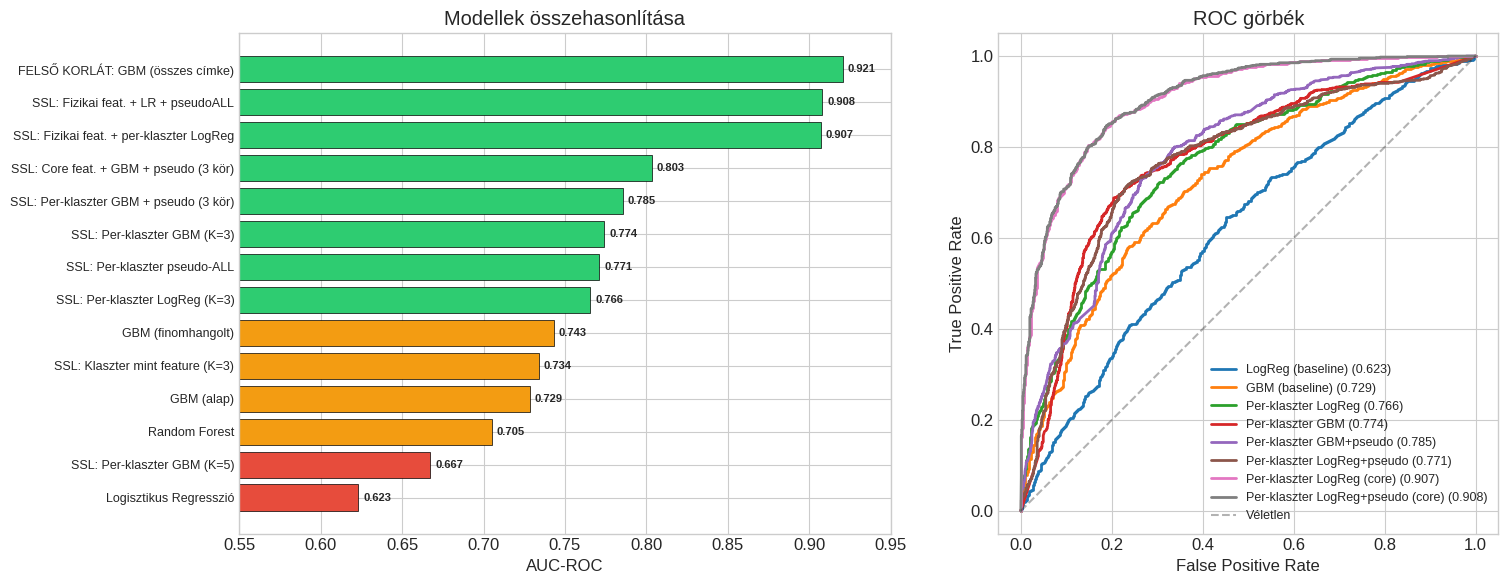

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

valid_results = {k: v for k, v in results.items() if v is not None}

if valid_results:
    sorted_results = sorted(valid_results.items(), key=lambda x: x[1])
    names = [r[0] for r in sorted_results]
    aucs = [r[1] for r in sorted_results]
    colors_bar = ['#e74c3c' if a < 0.70 else '#f39c12' if a < 0.76 else '#2ecc71' for a in aucs]

    bars = axes[0].barh(range(len(names)), aucs, color=colors_bar, edgecolor='black', linewidth=0.5)
    axes[0].set_yticks(range(len(names)))
    axes[0].set_yticklabels(names, fontsize=9)
    axes[0].set_xlabel('AUC-ROC')
    axes[0].set_title('Modellek összehasonlítása')
    axes[0].set_xlim(0.55, 0.95)
    axes[0].legend(fontsize=8)

    for bar, auc in zip(bars, aucs):
        axes[0].text(auc + 0.003, bar.get_y() + bar.get_height()/2, f'{auc:.3f}',
                    va='center', fontsize=8, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, "Nincs AUC-eredmény a megjelenítéshez",
                 horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes,
                 fontsize=12, color='gray')
    axes[0].set_title('Modellek összehasonlítása')
    axes[0].axis('off')

if y_test is not None:
    selected_preds = {
        'LogReg (baseline)': lr.predict_proba(X_test_s)[:, 1],
        'GBM (baseline)': gbm.predict_proba(X_test_s)[:, 1],
        'Per-klaszter LogReg': pred_lr,
        'Per-klaszter GBM': pred_gbm,
        'Per-klaszter GBM+pseudo': pred_pseudo3,
        'Per-klaszter LogReg+pseudo': pred_pseudo_all,
        'Per-klaszter LogReg (core)': pred_core_lr,
        'Per-klaszter LogReg+pseudo (core)': pred_core_lr_pseudo,
    }

    for name, pred in selected_preds.items():
        fpr, tpr, _ = roc_curve(y_test, pred)
        auc = roc_auc_score(y_test, pred)
        axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} ({auc:.3f})')

    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Véletlen')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC görbék')
    axes[1].legend(fontsize=9, loc='lower right')
    axes[1].set_aspect('equal')
else:
    axes[1].text(0.5, 0.5, "A ROC görbék nem jeleníthetők meg, mert hiányzik a teszt adatokhoz tartozó célváltozó (solution.csv).",
                 horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes,
                 fontsize=12, color='gray')
    axes[1].set_title('ROC görbék')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## Submission fájl generálása

A legjobb modell predikcióit elmentjük a Kaggle-nek megfelelő formátumban.

In [25]:
best_model_name = max(results, key=results.get)
print(f"Legjobb modell: {best_model_name} (AUC = {results[best_model_name]:.4f})")

# Submission generálása a legjobb SSL megoldással
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'Selejt': pred_pseudo3  # A legjobb SSL predikció
})

submission.to_csv('HUNXYZ_B_1.csv', index=False)
print(f"\nSubmission fájl mentve: {len(submission)} sor")
submission.head()

Legjobb modell: SSL: Per-klaszter GBM + pseudo (3 kör) (AUC = 0.7854)

Submission fájl mentve: 2000 sor


,ID,Selejt
0,ITEM_13000,0.997417
1,ITEM_13001,0.999141
2,ITEM_13002,0.997997
3,ITEM_13003,0.001669
4,ITEM_13004,0.001100
